In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from calcul_structure import *

In [2]:
## Propriété materiaux [N, m]
E = 2*10**8
I = 2000*10**(-6)
A = 1000*10**(-6)

#Element 1
L1 = 1 

# Nombre d'element
n_elements_ = 40
XY = np.zeros((n_elements_+1,2))
for i in range(n_elements_+1):
    XY[i, 0] = i * 1  # Setting the x-coordinate
    XY[i, 1] = 0       # Setting the y-coordinate (which is always 0 in this case)

print(XY[:,0].shape)

(41,)


In [3]:
#Matrice de rigidité élémentaire en coordonnées locales
mat_elem_local = matrice_elementaire(E, I, A, L1)

In [4]:
#Matrice de rotatio
rot_elem = rotation_matrice(0)
print(rot_elem.astype(int))

[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]


In [5]:
#Matrice de rigidité élémentaire en coordonnées locales
mat_elem_global = np.matmul(np.matmul(np.transpose(rot_elem),mat_elem_local), rot_elem)

In [6]:
# Connection entre élément
# Degré de liberte de chaque élément de la forme
# LM[:, i] = [Uxi, Uyi, Thetai, Uxj, Uyj, Thetaj]
# Travée 1
LM = np.zeros((6, 41), dtype=int)
LM[:,0] = [0, 0, 38, 0, 1, 39]
LM[:,1] = [0, 1, 39, 0, 2, 40]    
LM[:,2] = [0, 2, 40, 0, 3, 41]   
LM[:,3] = [0, 3, 41, 0, 4, 42]
LM[:,4] = [0, 4, 42, 0, 5, 43]   
LM[:,5] = [0, 5, 43, 0, 6, 44]
LM[:,6] = [0, 6, 44, 0, 7, 45]
LM[:,7] = [0, 7, 45, 0, 8, 46]
LM[:,8] = [0, 8, 46, 0, 9, 47]
LM[:,9] = [0, 9, 47, 0, 10, 48]
LM[:,10] = [0, 10, 48, 0, 11, 49]
LM[:,11] = [0, 11, 49, 0, 12, 50]
LM[:,12] = [0, 12, 50, 0, 13, 51]
LM[:,13] = [0, 13, 51, 0, 14, 52]
LM[:,14] = [0, 14, 52, 0, 0, 53]

#Travée 2
LM[:,15] = [0, 0,  53, 0,  15, 54]
LM[:,16] = [0, 15, 54, 0, 16, 55]
LM[:,17] = [0, 16, 55, 0, 17, 56]
LM[:,18] = [0, 17, 56, 0, 18, 57]
LM[:,19] = [0, 18, 57, 0, 19, 58]
LM[:,20] = [0, 19, 58, 0, 20, 59]
LM[:,21] = [0, 20, 59, 0, 21, 60]
LM[:,22] = [0, 21, 60, 0, 22, 61]
LM[:,23] = [0, 22, 61, 0, 23, 62]
LM[:,24] = [0, 23, 62, 0, 0,  63]

#Travée 3
LM[:,25] = [0, 0, 63, 0, 24, 64]
LM[:,26] = [0, 24,64, 0, 25, 65]
LM[:,27] = [0, 25,65, 0, 26, 66]
LM[:,28] = [0, 26,66, 0, 27, 67]
LM[:,29] = [0, 27,67, 0, 28, 68]
LM[:,30] = [0, 28,68, 0, 29, 69]
LM[:,31] = [0, 29,69, 0, 30, 70]
LM[:,32] = [0, 30,70, 0, 31, 71]
LM[:,33] = [0, 31,71, 0, 32, 72]
LM[:,34] = [0, 32,72, 0, 33, 73]
LM[:,35] = [0, 33,73, 0, 34, 74]
LM[:,36] = [0, 34,74, 0, 35, 75]
LM[:,37] = [0, 35,75, 0, 36, 76]
LM[:,38] = [0, 36,76, 0, 37, 77]
LM[:,39] = [0, 37,77, 0, 0, 78]
#LM[:,40] = [0, 38,79, 0, 0,  80]


# Nombre de DDL
n_ddl_  = 78

In [7]:
# addtionnner au composante differentde zeros
K_global = np.zeros((n_ddl_, n_ddl_), dtype=np.float32)
for i in range(n_elements_):
    K_global = assemblage_matrice_rigidite(LM, i, K_global, mat_elem_global)


In [8]:

#Matrice de force locale
w = 12
P1_local = np.array([[0], [-w*L1/2], [-w*L1**2/12],[0],[-w*L1/2], [w*L1**2/12]])
print(P1_local)

[[ 0.]
 [-6.]
 [-1.]
 [ 0.]
 [-6.]
 [ 1.]]


In [9]:
P1_global = np.matmul(np.transpose(rot_elem),P1_local)
print(P1_global)

[[ 0.]
 [-6.]
 [-1.]
 [ 0.]
 [-6.]
 [ 1.]]


# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1 CHARGÉ

In [10]:
P_global_trave_1 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(15):
    P_global_trave_1 = assemblage_vecteur_nodal(LM, i, P_global_trave_1, P1_global)

In [11]:
#Calcule des déplacements
U_trave_1 = np.linalg.solve(K_global, P_global_trave_1)

[-0.0002625]
41


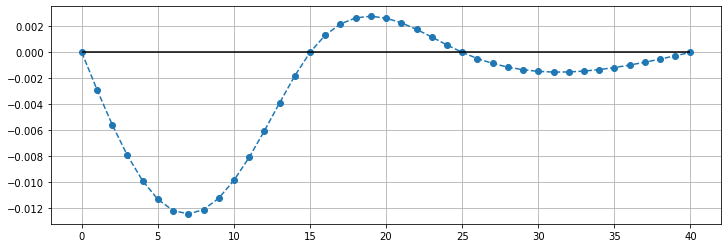

In [12]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_1 = list()
for i in range(n_elements_):
    deplacement_local_trave_1.append(obtention_du_deplacement_local(LM,i, U_trave_1))

delta_deplacement_trave_1 = np.zeros(n_elements_+1)
print(deplacement_local_trave_1[-1][1])
print(len(XY))
for j in range(len(deplacement_local_trave_1)):
    delta_deplacement_trave_1[j]= deplacement_local_trave_1[j][1]
    delta_deplacement_trave_1[j+1] = deplacement_local_trave_1[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:,0],delta_deplacement_trave_1,'o--')
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.show()

In [13]:
effort_interne_trave_1 = list()
for i in range(n_elements_):
    effort_interne_trave_1.append(mat_elem_local@rot_elem@deplacement_local_trave_1[i])

for i in range(15):
    effort_interne_trave_1[i] = effort_interne_trave_1[i]-P1_local


[   0  -69 -127 -173 -207 -229 -239 -237 -223 -197 -159 -109  -47   26
  112  210  185  160  134  109   84   59   33    8  -16  -42  -39  -36
  -33  -30  -28  -25  -22  -19  -16  -14  -11   -8   -5   -2    0]


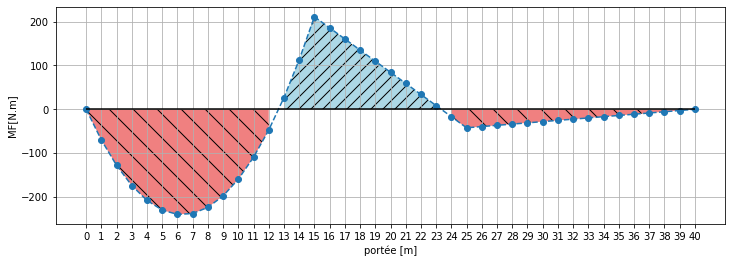

In [14]:
moment_flechissant_trave_1 =  np.zeros(n_elements_+1)
for j in range(len(effort_interne_trave_1)):
    moment_flechissant_trave_1[j] = effort_interne_trave_1[j][2]
    moment_flechissant_trave_1[j+1] = effort_interne_trave_1[j][5]

print(moment_flechissant_trave_1.astype(int))
x = XY[:, 0]
y = moment_flechissant_trave_1
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [94]:
effort_tranchant_trave_1 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_1[j] = effort_interne_trave_1[j][1]
    effort_tranchant_trave_1[j+1] = -effort_interne_trave_1[j][4]

print(effort_interne_trave_1[20][1].astype(int))

[25]


[ 75  63  51  39  27  15   3  -8 -20 -32 -44 -56 -68 -80 -92  25  25  25
  25  25  25  25  25  25  25  -2  -2  -2  -2  -2  -2  -2  -2  -2  -2  -2
  -2  -2  -2  -2  -2]


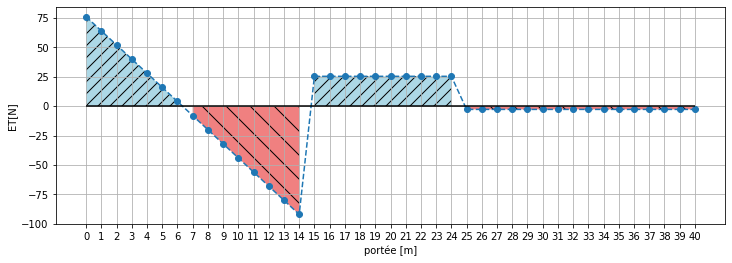

In [95]:
print(effort_tranchant_trave_1.astype(int))
y = effort_tranchant_trave_1
x = XY[:,0]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))

plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 2 CHARGÉ

In [17]:
P_global_trave_2 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 2
for i in range(15,25):
    P_global_trave_2 = assemblage_vecteur_nodal(LM, i, P_global_trave_2, P1_global)

In [18]:
#Calcule des déplacements
U_trave_2 = np.linalg.solve(K_global, P_global_trave_2)

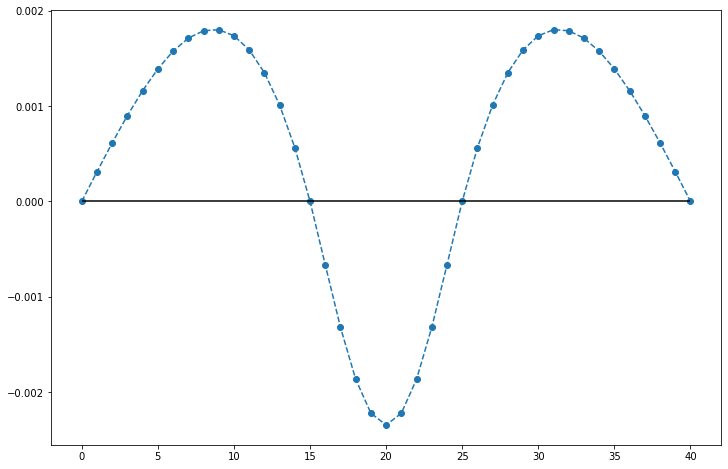

In [19]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_2 = list()
for i in range(n_elements_):
    deplacement_local_trave_2.append(obtention_du_deplacement_local(LM,i, U_trave_2))

delta_deplacement_trave_2 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_2[j]= deplacement_local_trave_2[j][1]
    delta_deplacement_trave_2[j+1] = deplacement_local_trave_2[j][4]
plt.figure(figsize=(12,8))
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_2,'o--')
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.show()

In [20]:
effort_interne_trave_2 = list()
for i in range(n_elements_):
    effort_interne_trave_2.append(mat_elem_local@rot_elem@deplacement_local_trave_2[i])

for i in range(15,25):
    effort_interne_trave_2[i] = effort_interne_trave_2[i]-P1_local

print(effort_interne_trave_2[0][1].astype(int))

[-3]


[   0    3    6   10   13   16   19   23   26   29   33   36   40   43
   46   50   -3  -46  -76  -93 -100  -93  -75  -46   -3   50   46   43
   39   36   33   29   26   23   19   16   13    9    6    3    0]


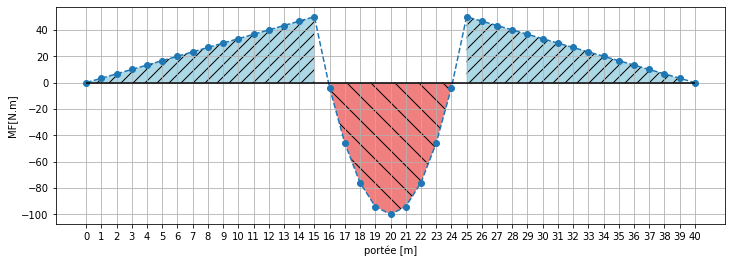

In [21]:
moment_flechissant_trave_2 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_2[j] = effort_interne_trave_2[j][2]
    moment_flechissant_trave_2[j+1] = effort_interne_trave_2[j][5]

print(moment_flechissant_trave_2.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_2
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [92]:
effort_tranchant_trave_2 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_2[j] = effort_interne_trave_2[j][1]
    effort_tranchant_trave_2[j+1] = -effort_interne_trave_2[j][4]

print(effort_interne_trave_2[20][1].astype(int))

[0]


[ -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  -3  59  48  35
  23  12   0 -11 -23 -36 -47   3   3   3   3   3   3   3   3   3   3   3
   3   3   3   3   3]
[59 48 35 23 12]


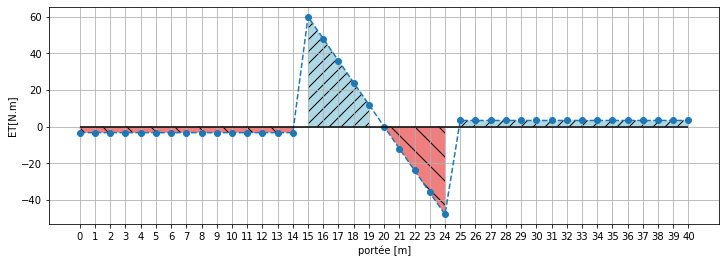

In [93]:
print(effort_tranchant_trave_2.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_2
print(y[15:20].astype(int))
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N.m]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1, 2 CHARGÉ

In [24]:
P_global_trave_12 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(25):
    P_global_trave_12 = assemblage_vecteur_nodal(LM, i, P_global_trave_12, P1_global)

In [25]:
#Calcule des déplacements
U_trave_12 = np.linalg.solve(K_global, P_global_trave_12)

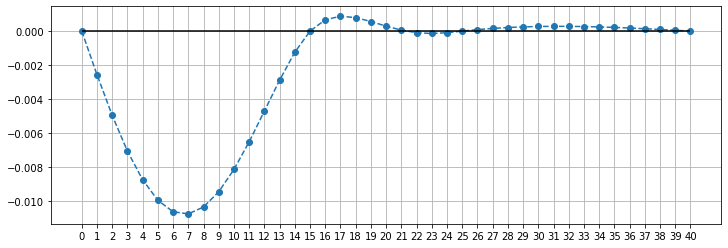

In [26]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_12 = list()
for i in range(n_elements_):
    deplacement_local_trave_12.append(obtention_du_deplacement_local(LM,i, U_trave_12))

delta_deplacement_trave_12 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_12[j]= deplacement_local_trave_12[j][1]
    delta_deplacement_trave_12[j+1] = deplacement_local_trave_12[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_12,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.show()

In [27]:
effort_interne_trave_12 = list()
for i in range(n_elements_):
    effort_interne_trave_12.append(mat_elem_local@rot_elem@deplacement_local_trave_12[i])

for i in range(15,20):
    effort_interne_trave_12[i] = effort_interne_trave_12[i]-P1_local

print(effort_interne_trave_12[0][1].astype(int))

[66]


[  -1  -67 -122 -164 -195 -214 -220 -215 -197 -168 -127  -73   -8   69
  158  260  181  114   58   15  -16  -35  -43  -38  -21    7    7    6
    6    5    5    4    4    3    3    2    2    1    1    0    0]


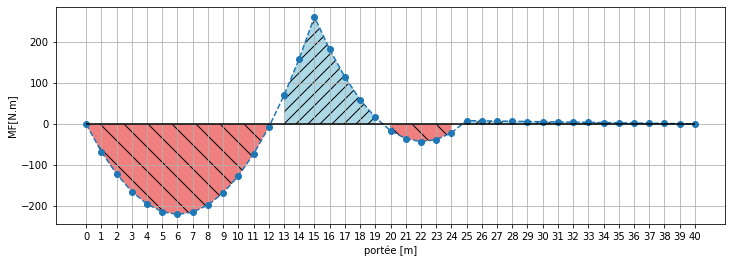

In [28]:
moment_flechissant_trave_12 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_12[j] = effort_interne_trave_12[j][2]
    moment_flechissant_trave_12[j+1] = effort_interne_trave_12[j][5]

print(moment_flechissant_trave_12.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_12
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [90]:
effort_tranchant_trave_12 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    effort_tranchant_trave_12[j] = effort_interne_trave_12[j][1]
    effort_tranchant_trave_12[j+1] = -effort_interne_trave_12[j][4]

print(effort_interne_trave_12[20][1].astype(int))

[19]


[  66   54   42   30   18    6   -5  -17  -29  -41  -53  -65  -77  -89
 -101   85   73   61   49   37   19    7   -4  -16  -28    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]
[85 73 61 49 37]


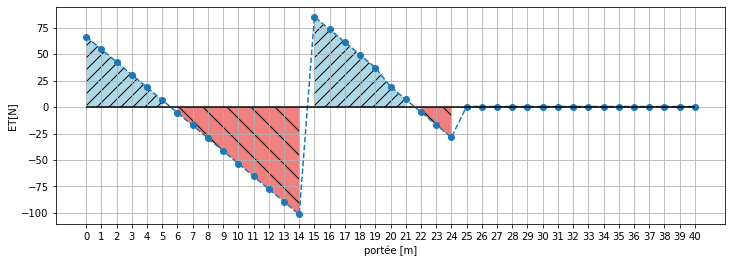

In [91]:
print(effort_tranchant_trave_12.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_12
print(y[15:20].astype(int))
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()

# CALCUL MOMENT FLECHISSANT ET EFFORT TRANCHANT POUR TRAVE 1, 3 CHARGÉ

In [47]:
P_global_trave_13 = np.zeros((n_ddl_,1), dtype=np.float32)

# chargement de la travée 1
for i in range(0, 15):
    P_global_trave_13 = assemblage_vecteur_nodal(LM, i, P_global_trave_13, P1_global)

for i in range(25, 40):
    P_global_trave_13 = assemblage_vecteur_nodal(LM, i, P_global_trave_13, P1_global)


In [48]:
#Calcule des déplacements
U_trave_13 = np.linalg.solve(K_global, P_global_trave_13)

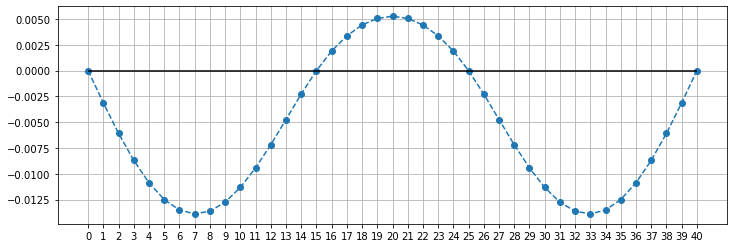

In [49]:
#Calcul des vecteurs de forces internes
deplacement_local_trave_13 = list()
for i in range(n_elements_):
    deplacement_local_trave_13.append(obtention_du_deplacement_local(LM,i, U_trave_13))

delta_deplacement_trave_13 = np.zeros(n_elements_+1)

for j in range(n_elements_):
    delta_deplacement_trave_13[j]= deplacement_local_trave_13[j][1]
    delta_deplacement_trave_13[j+1] = deplacement_local_trave_13[j][4]
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(XY[:n_elements_+1,0],delta_deplacement_trave_13,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.hlines(0, XY[0,0], XY[-1,0], colors='black')
plt.show()

In [52]:
effort_interne_trave_13 = list()
for i in range(n_elements_):
    effort_interne_trave_13.append(mat_elem_local@rot_elem@deplacement_local_trave_13[i])

for i in range(15):
    effort_interne_trave_13[i] = effort_interne_trave_13[i]-P1_local

for i in range(25,40):
    effort_interne_trave_13[i] = effort_interne_trave_13[i]-P1_local

print(effort_interne_trave_12[0][1].astype(int))

[66]


[   0  -72 -133 -182 -219 -243 -256 -257 -245 -222 -187 -140  -80   -9
   73  168  168  168  168  168  168  168  168  168  168  168   73   -9
  -80 -140 -187 -222 -245 -257 -256 -243 -219 -182 -133  -72    0]


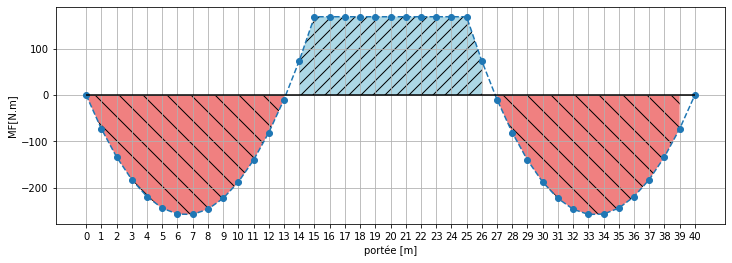

In [39]:
moment_flechissant_trave_13 =  np.zeros(n_elements_+1)
for j in range(n_elements_):
    moment_flechissant_trave_13[j] = effort_interne_trave_13[j][2]
    moment_flechissant_trave_13[j+1] = effort_interne_trave_13[j][5]

print(moment_flechissant_trave_13.astype(int))
x = XY[:n_elements_+1, 0]
y = moment_flechissant_trave_13
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('MF[N.m]')
plt.show()

In [89]:
effort_tranchant_trave_13 =  np.zeros(n_elements_+1)
for j in range(0,n_elements_):
    effort_tranchant_trave_13[j] = effort_interne_trave_13[j][1]
    effort_tranchant_trave_13[j+1] = -effort_interne_trave_13[j][4]


[ 78  66  54  42  30  18   6  -5 -17 -29 -41 -53 -65 -77 -89   0   0   0
   0   0   0   0   0   0   0 101  89  77  65  53  41  29  17   5  -6 -18
 -30 -42 -54 -66 -78]


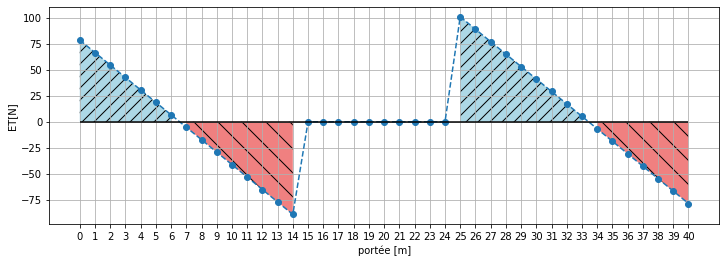

In [88]:
print(effort_tranchant_trave_13.astype(int))
x = XY[:n_elements_+1, 0]
y = effort_tranchant_trave_13

plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,y,'o--')
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')
plt.hlines(0, XY[0,0], XY[-1,0],colors='black')
# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')
plt.xlabel('portée [m]')
plt.ylabel('ET[N]')
plt.show()